In [1]:
# scientific libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from matplotlib.colors import ListedColormap
from skimage import io

# general libraries
import os  
import json
import time
import h5py as h5py
import copy

# jupyter imports
import ipywidgets as widgets
from IPython.display import clear_output

# local libraries
from analysis import *
from general_utils import *
from hdf_utils import unpack_hdf, Workspace
from scalebars import *
import deconv

# import balance_configs as configs
import tuning_ballstick_configs as configs
import experiments as exps
import analysis as ana
from interactive import MotionResponse

In [2]:
# %matplotlib notebook
# %matplotlib widget
%matplotlib ipympl
# %matplotlib qt
plt.rcParams.update({"figure.max_open_warning": 0})
plt.rcParams['svg.fonttype'] = 'none'  # don't save font as paths (assumes font present on machine)

In [3]:
base_path = "/mnt/Data/NEURONoutput/sac_net/"
model_path = os.path.join(base_path, "ballstick_tuning_runs")
fig_dir_path = os.path.join(model_path, "figs") 

exts = [".png", ".svg"]
bmb_green = "#009800ff"
bmb_magenta = "#fe36d0ff"

In [4]:
quanta_h5 = "/mnt/Data/prerna_velocity/static_roi_waveforms/quantum_pack.h5"
with h5.File(quanta_h5, "r") as f:
    quantum_pack = unpack_hdf(f)
    
release_rates = quantum_pack["clipped_rates"]
rec_dt = quantum_pack["rec_dt"]
# target_rate_dt = 0.001  # 0.0001
target_rate_dt = 0.005  # 0.0001
bp_inputs = {("sust" if k == "PD" else "trans"): r for k, r in quantum_pack["aligned_recs"].items()}
bp_inputs["sust"] = bp_inputs["sust"] * np.max(bp_inputs["trans"]) / np.max(bp_inputs["sust"])

vrate = deconv.velocity_rate(
    bp_inputs["trans"],
    rec_dt,
    quantum_pack["quantum"],
    1,
    rf=0.06,
    spot=0.2, # USUAL
    # spot=0.1, # CHANGED!
    # spot=0.05, # CHANGED!
    bsln_start=100,
    bsln_end=150,
    step=1,
    offset=0.,
    model_dt=target_rate_dt,
)
vrate = np.clip(vrate, 0.0, np.inf)

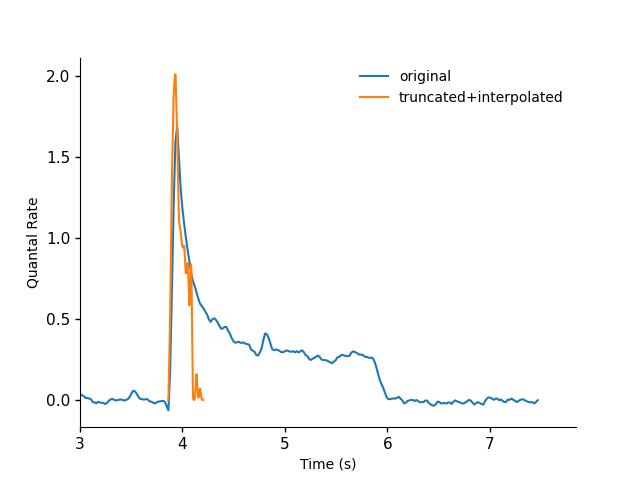

In [5]:
trans_rise = find_rise_bsln(bp_inputs["trans"], bsln_start=100, bsln_end=150, step=1) * rec_dt
rate_fig, rate_ax = plt.subplots(1)
rate_ax.plot(np.arange(len(bp_inputs["trans"])) * rec_dt, bp_inputs["trans"], label="original")
rate_ax.plot(np.arange(len(vrate)) * target_rate_dt + trans_rise, vrate, label="truncated+interpolated")
rate_ax.set_xlim(3)
rate_ax.set_xlabel("Time (s)")
rate_ax.set_ylabel("Quantal Rate")
rate_ax.legend(frameon=False)
clean_axes(rate_ax)

In [6]:
overwrite = False

save_name = "thesis_20tr_corelease_uncorr135-180_pref"
save_name = "thesis_20tr_corelease_uncorr135-180_pref_cor90_cor270"
save_name = "thesis_20tr_corelease_uncorr135-180_pref_cor90_ach90_cor270_ach270"

load_name = None

conditions = [
    ("corelease", (180, True, 180)),
    ("uncorr", (135, True, 180)),
    ("pref", (0, False, np.nan)),
    ("cor90", (90, True, 90)),
    ("ach90", (90, False, np.nan)),
    ("cor270", (270, True, 270)),
    ("ach270", (270, False, np.nan)),
]
cond_lbls, angle_picks = zip(*conditions)
times_picked, pick_idx = 0, 0
def fixed_picker(set_idx=None):
    global times_picked, pick_idx
    if set_idx is not None:
        pick_idx = set_idx
    else:
        times_picked += 1
        return angle_picks[pick_idx]
    
model_config = configs.thesis(
    {"sac": vrate / np.max(vrate), "glut": vrate / np.max(vrate), "dt": target_rate_dt},
    fixed_picker,
    ttx=True,
    non_ds_ach=False,
    offset_ampa_ach=False,
    record_tree=True,
)

model_config["synprops"]["E"]["weight"] = model_config["synprops"]["E"]["weight"]       #*0.45#*0.6#*0.6#*2 # * 0.5 #* 2 # CHANGED!
model_config["synprops"]["PLEX"]["weight"] = model_config["synprops"]["PLEX"]["weight"] #*0.45#*0.6#*0.6#*2 # * 0.5 #* 2 # CHANGED!
model_config["synprops"]["I"]["weight"] = model_config["synprops"]["I"]["weight"]       #*0.8#*0.8#*2  #* 0.8 #* 2 # CHANGED!
model_config["synprops"]["NMDA"]["weight"] = model_config["synprops"]["NMDA"]["weight"] #* 0.3#*0.3

# model_config["max_sac_rho"] = 1 # NEW NORMAL!
# model_config["max_sac_rho"] = 0.0
# model_config["min_sac_rho"] = 0.0
# model_config["min_sac_rho"] = 0.95
# model_config["min_sac_rho"] = 1 # FLAT MODE ON

# model_config["diam_range"]["min"] = 0.5
    
# model_config["sac_offset"] = 15  # CHANGED!

save_path = os.path.join(model_path, save_name) + ".h5"
if load_name is None:
    load_name = save_name
    if (not overwrite and os.path.exists(save_path)):
        print(
            "Loading %s rather than overwriting it.\nSet `overwrite = True` if saving over is desired."
            % save_name
        )
    else:
        from ei_balance_nogui import *
        os.makedirs(model_path, exist_ok=True)
        t0 = time.time()
        exps.sacnet_run(
            save_path,
            model_config,
            n_nets=len(angle_picks),
            n_trials=20,
            rho_steps=[1.], # not relevant with fixed_picker
            pool_sz=1,
            reset_seed_between_rho=True,
            reset_rng_before_runs=True,
        )
        print("rho run time:", time.time() - t0)

hdf = h5.File(os.path.join(model_path, load_name) + ".h5", "r")
d = Workspace(hdf, read_only=True)
fig_path = os.path.join(fig_dir_path, load_name)
os.makedirs(fig_path, exist_ok=True)

rhos = list(d.keys())
rho = rhos[0]  # always using 1.0 here
idxs = list(d[rhos[0]].keys())
print("==keys==")
print("rhos:", rhos)
print("idxs:", idxs)
print("exp keys:", list(d[rhos[0]][idxs[0]].keys()))
print("times fixed_picker called (double nets due to Rig init):", times_picked)

Loading thesis_20tr_corelease_uncorr135-180_pref_cor90_ach90_cor270_ach270 rather than overwriting it.
Set `overwrite = True` if saving over is desired.
==keys==
rhos: [1.0]
idxs: [0, 1, 2, 3, 4, 5, 6]
exp keys: ['dendrites', 'metrics', 'params', 'sac_net', 'soma', 'syn_locs']
times fixed_picker called (double nets due to Rig init): 0


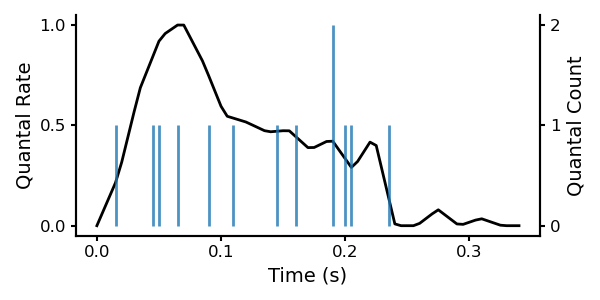

In [7]:
rng = np.random.default_rng()
xaxis = np.arange(len(vrate)) * target_rate_dt

# qrate = vrate * 0.5
# qrate = vrate / np.max(vrate)
qrate = model_config["sac_rate"]
release_fig, release_ax = plt.subplots(1, figsize=(6, 3))
quanta_ax = release_ax.twinx()
release_ax.plot(xaxis, qrate, lw=2, c="black")
release_ax.set_ylabel("Quantal Rate", fontsize=14)
rpq = deconv.poisson_of_release(rng, qrate)
_, quanta_stems, _ = quanta_ax.stem(
    xaxis,
    rpq,
    linefmt="-",
    markerfmt="none",
    basefmt="none",
)
quanta_stems.set_alpha(0.8)
quanta_stems.set_linewidth(2.)
# quanta_stems.set_color("black")
release_ax.set_yticks([0, 0.5, 1])
quanta_ax.set_yticks(np.arange(rpq.max() + 1))
release_ax.set_xticks([0, 0.1, 0.2, 0.3])
quanta_ax.set_ylabel("Quantal Count", fontsize=14)
release_ax.set_xlabel("Time (s)", fontsize=14)
clean_axes([release_ax, quanta_ax], ticksize=12, spine_width=1.5, remove_spines=["top"])
release_fig.tight_layout()
for ext in [".svg", ".png"]:
    release_fig.savefig(os.path.join(fig_path, "poisson_quanta_ex" + ext), bbox_inches="tight")

In [8]:
def close_button():
    button = widgets.Button(description="Close Workspace")
    out = widgets.Output()

    def on_clicked(_):
        with out:
            clear_output()
            d.close()
            print("File closed!")
        
    button.on_click(on_clicked)
    return widgets.VBox([button, out])

close_button()

In [9]:
metrics = ana.get_sac_metrics(d)

dir_labels = d[rhos[0]][idxs[0]]["params"]["dir_labels"][:]
sac_thetas = ana.get_sac_thetas(d)
sac_deltas = ana.get_sac_deltas(sac_thetas)
tuning = (ana.analyze_tree(d, dir_labels, pref=0, thresh=-56)
          if "dendrites" in d[rhos[0]][idxs[0]].keys() 
          else None)

n_trials, n_dirs, _ = d[rho][idxs[0]]["soma"]["Vm"][:].shape
soma_vm_avg = {net: np.mean(d[rho][net]["soma"]["Vm"][:], axis=0) for net in idxs}
term_vm_avg = {net: np.mean(d[rho][net]["dendrites"]["Vm"][:, :, -1], axis=0) for net in idxs}
term_cai_avg = {net: np.mean(d[rho][net]["dendrites"]["cai"][:, :, -1], axis=0) for net in idxs}

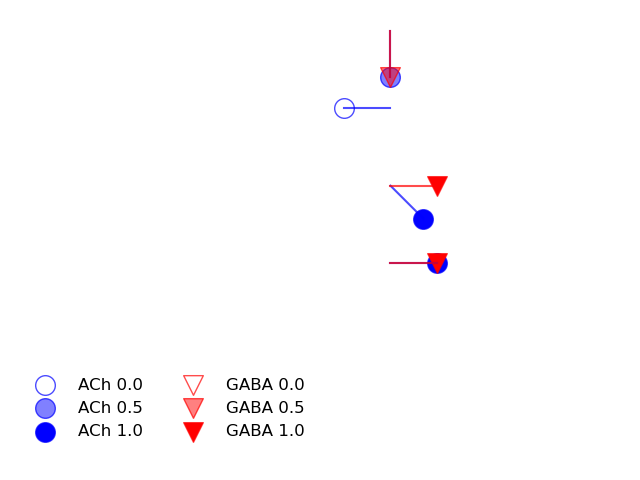

In [10]:
stim_angle = 180
# rho1 net0 n6 seed17 plex4
csteps = 512
clr = "black"

loc_offsets = np.array([[0, 0, 0], [0, 50, 0], [0, 100, 0]])
loc_offsets = np.array([[0, i * 50, 0] for i in idxs])
syn_locs = np.concatenate([d[rho][n]["syn_locs"] for n in idxs], axis=0) + loc_offsets
bp_locs = {
    k: np.concatenate([d[rho][n]["sac_net"]["wiring"]["bp_locs"][k] for n in idxs], axis=0
                     ) + loc_offsets[:, :2] 
    for k in ["E", "I"]
}
probs = {
    k: np.concatenate([d[rho][n]["sac_net"]["wiring"]["probs"][k] for n in idxs], axis=0) 
    for k in ["E", "I"]
}

gamma = 0.01
min_size = None
c_clear = mpl.colors.colorConverter.to_rgba("white", alpha = 0)
c_black = mpl.colors.colorConverter.to_rgba("black", alpha = 1)
c_red = mpl.colors.colorConverter.to_rgba("red", alpha = 1)
c_blue = mpl.colors.colorConverter.to_rgba("blue", alpha = 1)
cmap = mpl.colors.LinearSegmentedColormap.from_list("rb_cmap", [c_clear, c_black], csteps, gamma=gamma)
ach_cmap = mpl.colors.LinearSegmentedColormap.from_list("rb_cmap", [c_clear, c_blue], csteps, gamma=gamma)
gaba_cmap = mpl.colors.LinearSegmentedColormap.from_list("rb_cmap", [c_clear, c_red], csteps, gamma=gamma)
    
over_fig, over_ax = plt.subplots(1)
ana.plot_dends_overlay(
    over_fig,
    over_ax,
    syn_locs,
    bp_locs,
    probs,
    dir_labels,
    stim_angle=stim_angle,
    n_syn=len(syn_locs),
    # sac_alpha=None,
    # sac_thickness=2,
    dsgc_alpha=0,
    sac_thickness=1.5,
    sac_marker_size=200,
    sac_min_marker_size=min_size,
    syn_choice_seed=0,
    # ach_color="green",
    # gaba_color="cyan",
    ach_color="blue",
    gaba_color="red",
    # ach_edge="black",
    # gaba_edge="black",
    ach_edge="blue",
    gaba_edge="red",
    cmap=cmap,
    ach_cmap = ach_cmap,
    gaba_cmap = gaba_cmap,
    cbar_orientation="vertical",
    incl_cbars=False,
)
# net0 n20 seeds 21 44 45 52 60 71
# net0 n16 seeds 316 336
# net0 n12 seeds 259 402 403

# NOTE: the params of the sac net that was used for the thesis fig, but they do not produce the same result 
# any longer (due to changes to make the numpy rng usage more consistent)
# /mnt/Data/NEURONoutput/sac_net/model_runs/figs/pre_poissarma_decr_conf/decr_conf_5ms_step_weight_x2_Na0p035_K0p035_order2/sac_net_rho1p0_net0_dir0_n20_seed13_plex.svg 
over_fig.set_layout_engine("tight")

if 1:
    size_lbl = "_sized" if min_size is not None else ""
    for ext in [".png", ".svg"]:
        name = "sac_net_rho%s_dir%i_gamma%.2f%s%s" % (
            str(rho).replace(".", "p"),
            stim_angle,
            gamma,
            size_lbl,
            ext
        )
        over_fig.savefig(os.path.join(fig_path, name))

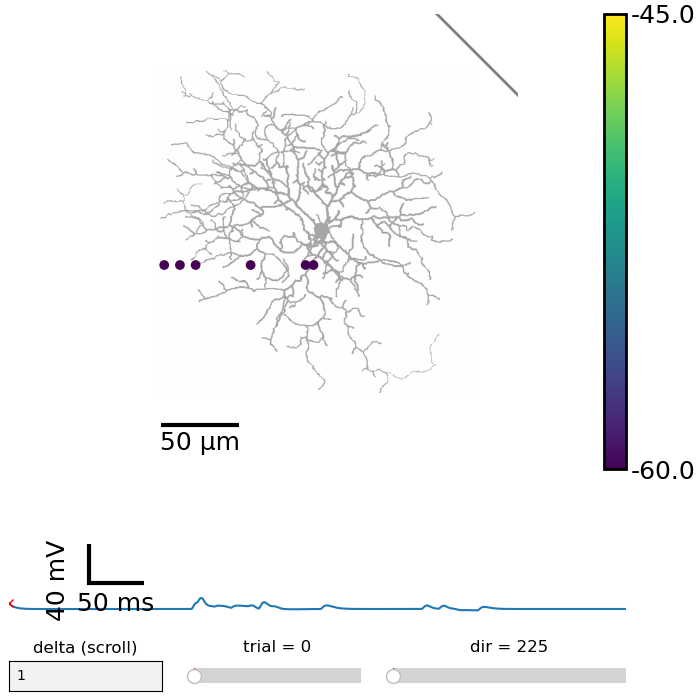

In [11]:
# TODO: make MotionResponse cope if "dendrites" dataset is missing
# (still have spiking and stim visualization with blank dendrites)
mr_scalebar_mode = True
if tuning is not None:
    rho = 1.0
    net = 0
    mr = MotionResponse(
        d[rho][net], 
        tree_k="Vm",
        figsize=(7, 7), 
        tree_vmin=-60,
        tree_vmax=-45,
        soma_vmin=-70,
        soma_vmax=50,
    )
    if mr_scalebar_mode:
        clean_axes(mr.soma_ax, remove_spines=["left", "right", "top", "bottom"])
        clean_axes(mr.tree_ax, remove_spines=["left", "right", "top", "bottom"])
        vm_sizex = 50
        vm_sizey = 40
        add_scalebar(
            mr.soma_ax,
            matchx=False, 
            matchy=False, 
            sizex=vm_sizex, 
            sizey=vm_sizey, 
            labelx="%i ms" % vm_sizex,
            labely="%i mV" % vm_sizey,
            sep=5,
            barwidth=3,
            loc="center",
            bbox_to_anchor=(100, 120),
            textprops={"fontsize": 18},
            ytextprops={"rotation": "vertical"},
        )
        tree_sizex = 50
        add_scalebar(
            mr.tree_ax,
            matchx=False, 
            matchy=False, 
            sizex=tree_sizex, 
            labelx="%i μm" % tree_sizex,
            sep=5,
            barwidth=3,
            loc="center",
            bbox_to_anchor=(200, 260),
            textprops={"fontsize": 18},
        )
    ticks = [mr.colorbar.vmin, mr.colorbar.vmax]
    mr.colorbar.set_ticks(ticks, labels=ticks, size=18)
    mr.colorbar_ax.tick_params(width=0, size=0)
    mr.colorbar.outline.set_linewidth(2)


In [12]:
close_button()

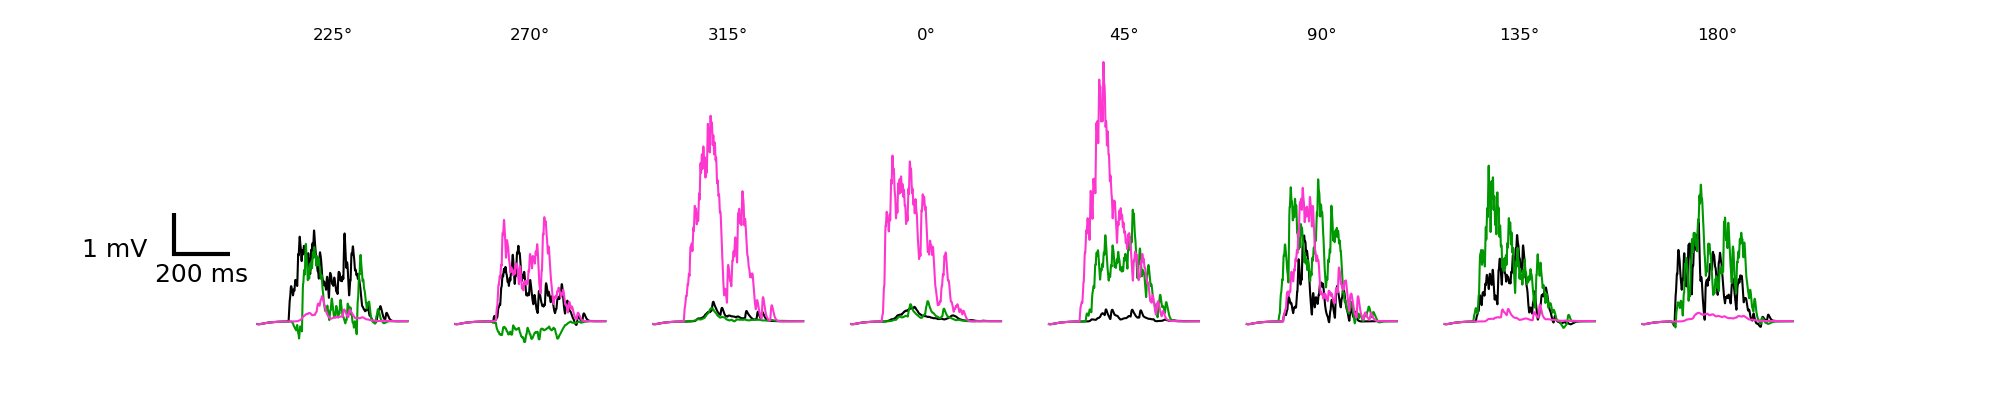

In [13]:
show_idxs = idxs
show_idxs = [0, 1, 2]
trial = None
dir_titles = True
start_t = 300
shadows = False
shadows_alpha = 0.3

clrs = ["black", bmb_green, bmb_magenta, "blue", "red"]
clrs = clrs + ["C%i" % i for i in range(len(idxs) - len(clrs))]
vm_pts = d[rho][net]["soma"]["Vm"].shape[-1]
vm_xaxis = np.linspace(0, vm_pts * d[rho][net]["params"]["dt"], vm_pts)

soma_vm_fig, soma_vm_ax = plt.subplots(1, len(dir_labels), sharex=True, sharey=True, figsize=(20, 4))
for net in show_idxs:
    for i in range(len(dir_labels)):
        vm = soma_vm_avg[net] if trial is None else d[rho][net]["soma"]["Vm"][trial]
        if trial is None and shadows:
            for tr in range(n_trials):
                soma_vm_ax[i].plot(
                    vm_xaxis[start_t:], d[rho][net]["soma"]["Vm"][tr, i, start_t:], 
                    c=clrs[net], alpha=shadows_alpha
                )
        soma_vm_ax[i].plot(vm_xaxis[start_t:], vm[i, start_t:], c=clrs[net])
        soma_vm_ax[i].patch.set_alpha(0)

if dir_titles:
    for i, lbl in enumerate(dir_labels):
        soma_vm_ax[i].set_title("%i°" % lbl)
        
clean_axes(soma_vm_ax, remove_spines=["left", "right", "top", "bottom"])

sizex = 200
sizey = 1 if trial is None else 5
add_scalebar(
    soma_vm_ax[0], 
    matchx=False, 
    matchy=False, 
    sizex=sizex, 
    sizey=sizey, 
    labelx="%i ms" % sizex,
    labely="%i mV" % sizey,
    sep=5,
    barwidth=3,
    loc="center",
    bbox_to_anchor=(165, 150),
    textprops={"fontsize": 18},
)

trial_lbl = "avg" if trial is None else str(trial)
name = os.path.join(fig_path, "soma_vm_net%i_trial%s" % (net, trial_lbl))
for ext in [".png", ".svg"]:
    soma_vm_fig.savefig(name + ext)

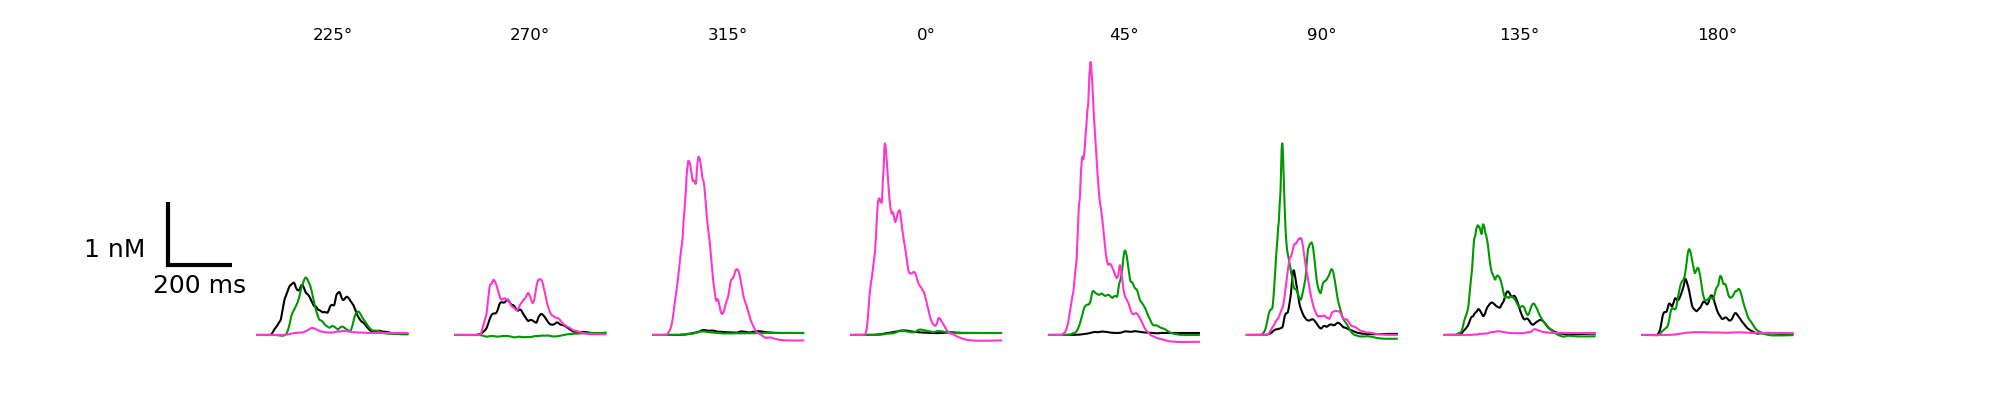

In [14]:
show_idxs = idxs
show_idxs = [0, 1, 2]
trial = None
dir_titles = True
start_t = 100

clrs = ["black", bmb_green, bmb_magenta, "blue", "red"]
clrs = clrs + ["C%i" % i for i in range(len(idxs) - len(clrs))]
cai_pts = term_cai_avg[0].shape[-1]
dwnsmpl = vm_pts // cai_pts
cai_min = np.min([term_cai_avg[net].min() for net in idxs])
cai_max = np.max([term_cai_avg[net].max() for net in idxs])
term_cai_avg_peak = {net: np.max(term_cai_avg[net][:, start_t:], axis=-1) for net in idxs}
cai_xaxis = np.linspace(0, dwnsmpl * d[rho][net]["params"]["dt"] * cai_pts, cai_pts)

term_cai_fig, term_cai_ax = plt.subplots(1, len(dir_labels), sharex=True, sharey=True, figsize=(20, 4))
for net in show_idxs:
    for i in range(len(dir_labels)):
        cai = term_cai_avg[net] if trial is None else d[rho][net]["dendrites"]["cai"][trial, :, -1]
        term_cai_ax[i].plot(cai_xaxis[start_t:], cai[i, start_t:] * 1e6, c=clrs[net])
        term_cai_ax[i].patch.set_alpha(0)

if dir_titles:
    for i, lbl in enumerate(dir_labels):
        term_cai_ax[i].set_title("%i°" % lbl)
        
clean_axes(term_cai_ax, remove_spines=["left", "right", "top", "bottom"])

cai_sizex = 200
cai_sizey = 100 if trial is None else 500
add_scalebar(
    term_cai_ax[0], 
    matchx=False, 
    matchy=False, 
    sizex=cai_sizex, 
    sizey=cai_sizey, 
    labelx="%i ms" % sizex,
    labely="%i nM" % sizey,
    sep=5,
    barwidth=3,
    loc="center",
    bbox_to_anchor=(165, 150),
    textprops={"fontsize": 18},
)

trial_lbl = "avg" if trial is None else str(trial)
name = os.path.join(fig_path, "term_cai_net%i_trial%s" % (net, trial_lbl))
for ext in [".png", ".svg"]:
    term_cai_fig.savefig(name + ext)

polar radius = 472.84999999999997


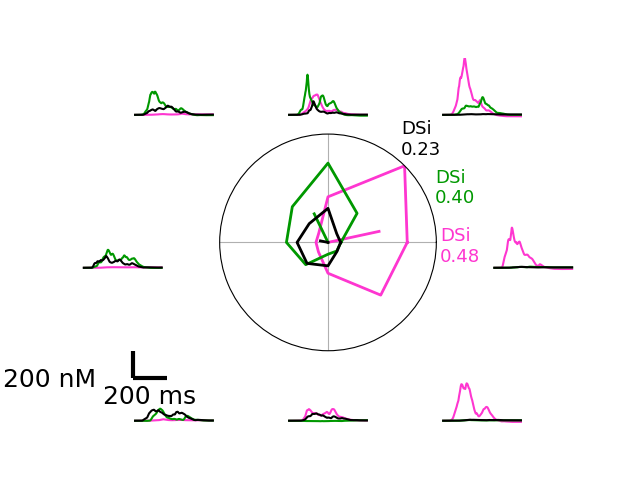

In [45]:
show_idxs = idxs
show_idxs = list(reversed(idxs))
show_idxs = [2, 1, 0]
# show_idxs = [4, 3, 2, 0]
# show_idxs = [0]

clrs = ["black", bmb_green, bmb_magenta, "blue", "red"]
clrs = clrs + ["C%i" % i for i in range(len(idxs) - len(clrs))]

cai_polar_fig = plt.figure()
gs = cai_polar_fig.add_gridspec(nrows=5, ncols=5)
cai_polar_ax = cai_polar_fig.add_subplot(gs[1:4, 1:4], projection="polar")

dir_subs = [gs[4, 0], gs[4, 2], gs[4, 4], gs[2, 4], gs[0, 4], gs[0, 2], gs[0, 0], gs[2, 0]]
s = 0.08
dir_shifts = [s, 0, -s, 0, -s, 0, s, 0]
dir_avg_ax = [cai_polar_fig.add_subplot(g) for g in dir_subs]
for i, ax in enumerate(dir_avg_ax):
    (x0, y0, w, h) = ax.get_position().bounds
    ax.set_position((x0 + dir_shifts[i], y0, w, h))

cai_plr_sizey = cai_sizey 
cai_plr_sizey = 200
add_scalebar(
    dir_avg_ax[0],
    matchx=False, 
    matchy=False, 
    sizex=cai_sizex, 
    sizey=cai_plr_sizey, 
    labelx="%i ms" % sizex,
    labely="%i nM" % cai_plr_sizey,
    sep=5,
    barwidth=3,
    loc="center",
    bbox_to_anchor=(100, 100),
    textprops={"fontsize": 18},
)

radius = (cai_max - cai_min) * 1e6
print("polar radius = %s" % str(radius))
for i, net in enumerate(show_idxs):
    polar(
        (term_cai_avg_peak[net] - cai_min).reshape(1, 1, 8) * 1e6,
        dir_labels,
        radius=radius,
        title=None,
        fig=cai_polar_fig,
        ax=cai_polar_ax,
        title_metrics=False,
        avg_colour=clrs[net],
        dsi_tag_deg=(30 * (i - 1))
    )
    for j, ax in enumerate(dir_avg_ax):
        ax.plot(cai_xaxis[start_t:], term_cai_avg[net][j, start_t:] * 1e6, c=clrs[net])

for ax in dir_avg_ax:
    ax.set_ylim(cai_min * 1e6, cai_max * 1e6)
    
cai_polar_ax.set_rticks([])
clean_axes(dir_avg_ax, remove_spines=["top", "bottom", "left", "right"])

nets_lbl = "_".join([cond_lbls[i] for i in show_idxs])
name = os.path.join(fig_path, "avg_cai_%s_polar" % (nets_lbl))
for ext in [".png", ".svg"]:
    cai_polar_fig.savefig(name + ext)

polar radius = 613.875


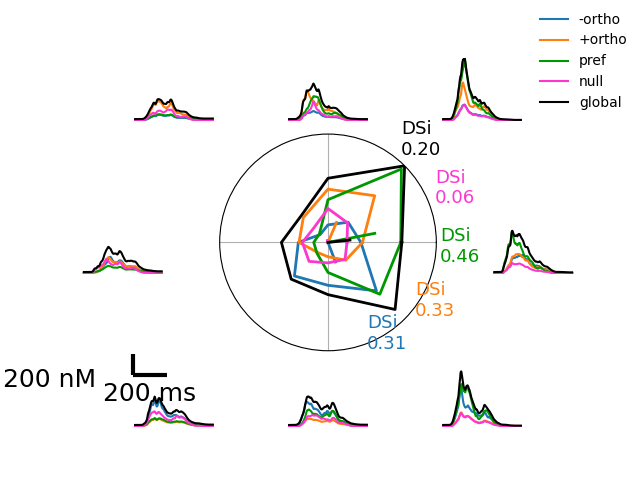

In [60]:
global_sum = True
add_in_global = True
show_pops = ["-ortho", "+ortho", "pref", "null", "global"]
# show_pops = ["-ortho", "+ortho", "pref", "null"]
clrs = ["black", bmb_green, bmb_magenta, "blue", "red"]
clrs = ["C0", "C1", bmb_green, bmb_magenta, "black"]

term_cai_avg_sub = map_data(lambda a: a - np.min(a[:, start_t:]), term_cai_avg)
pop_term_cai_avg = {
    "null": term_cai_avg_sub[0],
    "pref": term_cai_avg_sub[2],
    "+ortho": (term_cai_avg_sub[3] + term_cai_avg_sub[4]) / 2,
    "-ortho": (term_cai_avg_sub[5] + term_cai_avg_sub[6]) / 2,
}

global_signal = np.mean(np.stack(list(pop_term_cai_avg.values()), axis=0), axis=0)
if add_in_global:
    pop_term_cai_avg = map_data(lambda a: a + global_signal, pop_term_cai_avg)
pop_term_cai_avg["global"] = global_signal * (len(pop_term_cai_avg) if global_sum else 1)
pop_term_cai_avg_peak = {
    k: np.max(pop_term_cai_avg[k][:, start_t:], axis=-1) for k in pop_term_cai_avg.keys()}
pop_cai_max = np.max(list(pop_term_cai_avg_peak.values()))
show_pop_to_idx = {k: i for i, k in enumerate(show_pops)}

cai_pop_polar_fig = plt.figure()
gs = cai_pop_polar_fig.add_gridspec(nrows=5, ncols=5)
cai_pop_polar_ax = cai_pop_polar_fig.add_subplot(gs[1:4, 1:4], projection="polar")

dir_subs = [gs[4, 0], gs[4, 2], gs[4, 4], gs[2, 4], gs[0, 4], gs[0, 2], gs[0, 0], gs[2, 0]]
s = 0.08
dir_shifts = [s, 0, -s, 0, -s, 0, s, 0]
dir_avg_ax = [cai_pop_polar_fig.add_subplot(g) for g in dir_subs]
for i, ax in enumerate(dir_avg_ax):
    (x0, y0, w, h) = ax.get_position().bounds
    ax.set_position((x0 + dir_shifts[i], y0, w, h))

cai_plr_sizey = cai_sizey 
cai_plr_sizey = 200
add_scalebar(
    dir_avg_ax[0],
    matchx=False, 
    matchy=False, 
    sizex=cai_sizex, 
    sizey=cai_plr_sizey, 
    labelx="%i ms" % sizex,
    labely="%i nM" % cai_plr_sizey,
    sep=5,
    barwidth=3,
    loc="center",
    bbox_to_anchor=(100, 100),
    textprops={"fontsize": 18},
)
    
pop_radius = pop_cai_max * 1e6
print("polar radius = %s" % str(pop_radius))
for i, pop in enumerate(show_pops):
    polar(
        # (pop_term_cai_avg_peak[pop] - cai_min).reshape(1, 1, 8) * 1e6,
        (pop_term_cai_avg_peak[pop] * 1e6).reshape(1, 1, 8),
        dir_labels,
        radius=pop_radius,
        title=None,
        fig=cai_pop_polar_fig,
        ax=cai_pop_polar_ax,
        title_metrics=False,
        avg_colour=clrs[show_pop_to_idx[pop]],
        dsi_tag_deg=(30 * (i - 1) - 60)
    )
    for j, ax in enumerate(dir_avg_ax):
        lbl = None if j else pop
        ax.plot(
            cai_xaxis[start_t:], pop_term_cai_avg[pop][j, start_t:] * 1e6,
            c=clrs[show_pop_to_idx[pop]], label=lbl
        )

for ax in dir_avg_ax:
    ax.set_ylim(0, pop_cai_max * 1e6)
    
cai_pop_polar_ax.set_rticks([])
clean_axes(dir_avg_ax, remove_spines=["top", "bottom", "left", "right"])
cai_pop_polar_fig.legend(frameon=False)

pops_lbl = "_".join(show_pops)
global_mode_lbl = "gsum" if global_sum else "gmean"
global_lbl = "_plus_global" if add_in_global else ""
name = os.path.join(fig_path, "sac_pop_avg_cai_%s%s_%s_polar" % (global_mode_lbl, global_lbl, pops_lbl))
for ext in [".png", ".svg"]:
    cai_pop_polar_fig.savefig(name + ext)

In [17]:
list(d.keys())

[1.0]

In [18]:
list(d[rhos[0]][idxs[0]]["dendrites"].keys())

['Vm', 'cai', 'g', 'iCa', 'locs']

In [19]:
d[rhos[0]][idxs[0]]["dendrites"]["cai"]

<HDF5 dataset "cai": shape (20, 8, 6, 550), type "<f8">

In [20]:
d[rhos[0]][idxs[0]]["dendrites"]["Vm"]

<HDF5 dataset "Vm": shape (20, 8, 6, 2750), type "<f8">

In [21]:
dir_labels

array([225, 270, 315,   0,  45,  90, 135, 180])